In [1]:
# 1. Import libraries.

In [2]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install --upgrade seaborn

    #Data Manipulation / Handling data
import pandas as pd  #For loading data, data exploration 
import numpy as np # for data manipulation 

    #Data visualization
import matplotlib.pyplot as plt  #For plotting feature importance
import seaborn as sns  #For Exploratory data visualization to create correlation heatmaps

        #Machine learning
    #Data Preprocessing
from sklearn.model_selection import train_test_split   # for spliting data
from sklearn import preprocessing   #forscaling and encoding

    #Feature Selection
from sklearn.feature_selection import SelectKBest 
from sklearn.feature_selection import  f_regression

    #Modeling
from sklearn.ensemble import RandomForestRegressor

    #Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV


    #Model Evaluation
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score 
from sklearn.metrics import mean_absolute_error

    #Others
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#Can we utilize the random forest regressor model to predict the factors influencing BMW Sales volume between 
#2010 and 2024 across various regions?

In [4]:
#File path variables

Local_path = 'C:/Users/beatr/OneDrive/Desktop/WGU/D214/Task1/Data/'

InputFilePath = Local_path + 'BMW sales data (2010-2024).csv'

OutputfilePath =  Local_path + 'BMW_cleaned_df.csv'

XtrainOutputfilePath =Local_path + 'Xtrain.csv'

XtestOutputfilePath =Local_path + 'Xtest.csv'

ytrainOutputfilePath =Local_path + 'ytrain.csv'

ytestOutputfilePath =Local_path + 'ytest.csv'

TargetVariable  ="Sales_Volume"




In [5]:
#  2. Load the data.

In [6]:

#Loading the data
#Churn_df = pd.read_csv(InputFilePath,index_col=0)
BMW_df = pd.read_csv(InputFilePath)

In [7]:
#Initial data exploration (Understanding the data)

In [8]:
pd.set_option('display.max_columns', None)
BMW_df.head()


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [9]:
BMW_df.shape

(50000, 11)

In [10]:
BMW_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [11]:
# 3. Preprocessing (Cleaning) - includes removing outliers, white spaces, NULL/ NAN 
#values, imputing missing data, binding, one-hot encoding, etc.  

In [12]:
#Checking for Nulls and missing data

print(BMW_df[BMW_df[BMW_df.columns[BMW_df.isna().any()]].columns].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Empty DataFrame
None


In [13]:
#Trim and clean white spaces
BMW_df=BMW_df.map(lambda x: x.strip() if isinstance(x,str)else x)

In [14]:
#Checking for duplicated data 

print("Duplicated rows")
print(BMW_df.duplicated().any())
print(" ")
print("Duplicated columns")
print(BMW_df.columns.duplicated().any())


Duplicated rows
False
 
Duplicated columns
False


In [15]:
#Checking for unique values

BMW_df.nunique()

Model                      11
Year                       15
Region                      6
Color                       6
Fuel_Type                   4
Transmission                2
Engine_Size_L              36
Mileage_KM              44347
Price_USD               38246
Sales_Volume             9845
Sales_Classification        2
dtype: int64

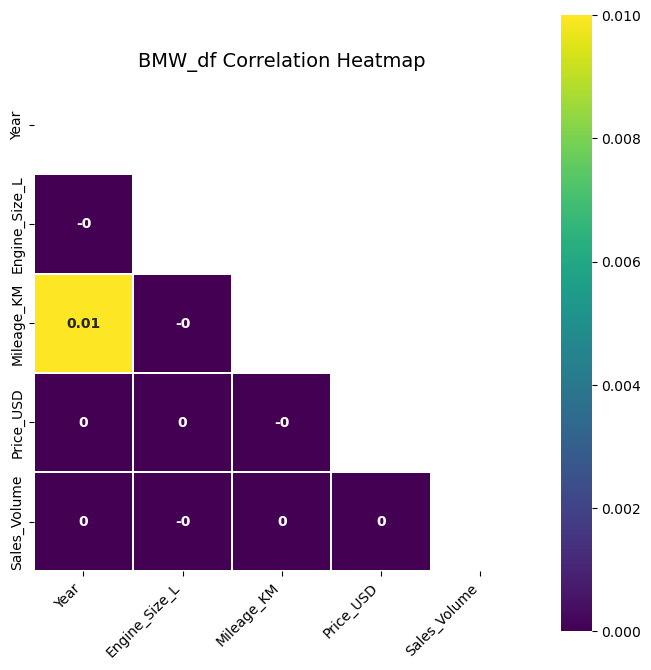

In [16]:
#Analysing the Correlation  /Relationship analysis
Continous_columns = BMW_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
Cor_data = BMW_df[Continous_columns]

def Generate_heatmap_graph(corr, chart_title, mask_uppertri=False):
    """ Based on features, generate a correlation matrix """
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = mask_uppertri
    fig, ax = plt.subplots(figsize=(8, 8))
    sns.heatmap(corr,
                mask=mask,
                square=True,
                annot=True,
                annot_kws={'size': 10, 'rotation': 0, 'weight': 'bold'},
                cmap=plt.get_cmap('viridis'),
                linewidths=.1,
                ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x-axis labels
    plt.title(chart_title, fontsize=14)
    plt.show()
var_corr = round(Cor_data.corr(), 2)
Generate_heatmap_graph(var_corr, chart_title='BMW_df Correlation Heatmap', mask_uppertri=True)

In [17]:
#Dropping Columns that will not be used in the analysis 
BMW_df = BMW_df.drop (columns = ['Sales_Classification'])

Distribution of Numerical data


<Figure size 1400x1000 with 0 Axes>

<Figure size 1000x2000 with 0 Axes>

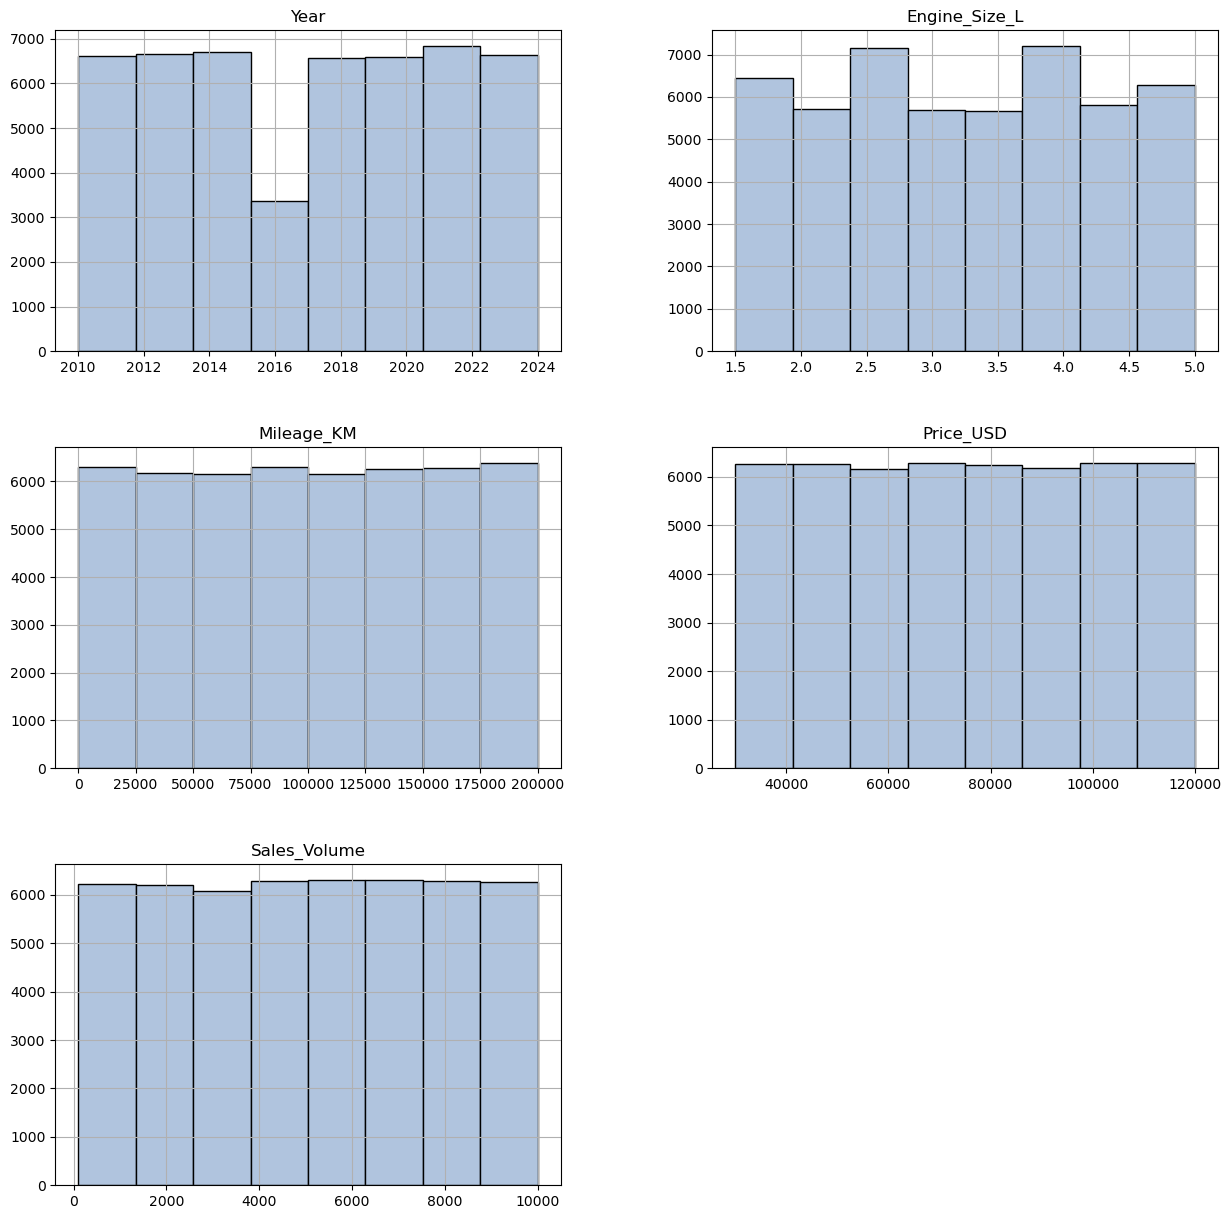

Distribution of Categorical data


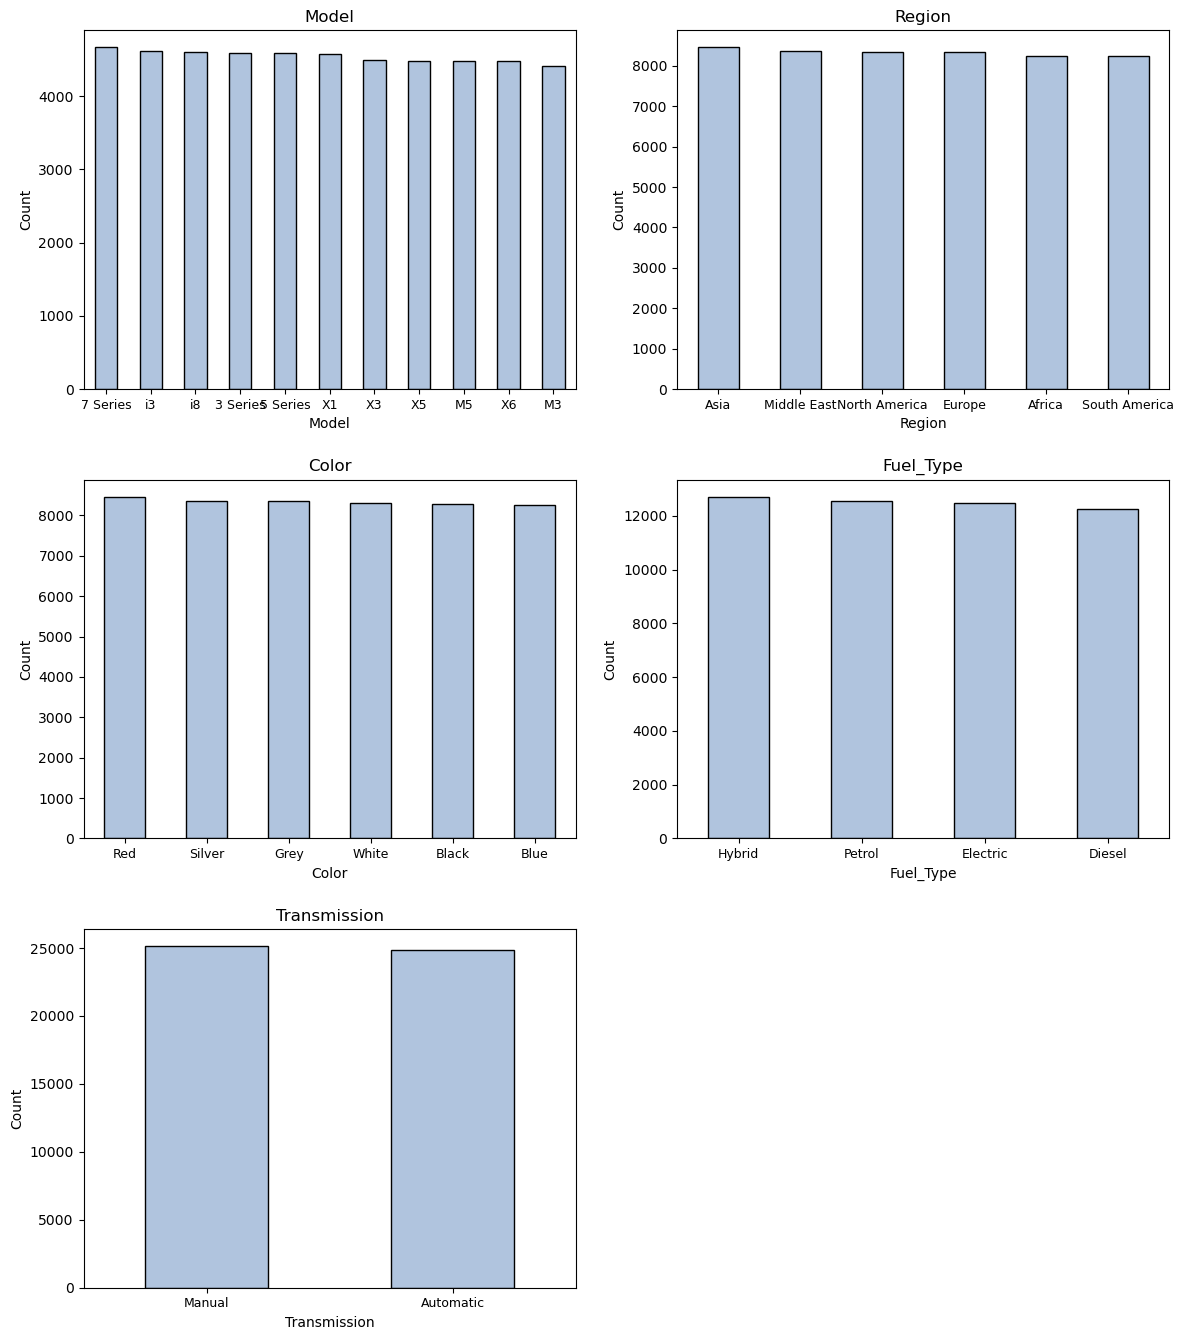

In [18]:
#Visualization of the data for Exploratory purposes
# Suppress all UserWarnings
warnings.filterwarnings("ignore", category=UserWarning)

# Set the figure size for the plots
plt.figure(figsize=(14, 10))

#  Visualization of numeric features /Outlier detection
print('Distribution of Numerical data')

Continous_columns = BMW_df.select_dtypes(include=['float64','int64']).columns
fig = plt.figure(figsize=(10, 20))
ax = BMW_df[Continous_columns].hist(bins = 8, figsize=(15,15),color='lightsteelblue', edgecolor='black')
plt.title('Distibution of Numerical data')
fig.tight_layout(h_pad=5, w_pad=5)
plt.show()

# Visualization of Categorical data

print('Distribution of Categorical data')
# Distribution of Categorical data
Categorical_data = BMW_df.select_dtypes(exclude=['float64', 'int64']).columns

n_cols = 2 # Number of graphs per row
n_rows = -(-len(Categorical_data) // n_cols)  


fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4.5 * n_rows))

# Flatten axes for easy iteration if more than one row
axes = axes.flatten()

for i, col in enumerate(Categorical_data):
    BMW_df[col].value_counts().plot(kind='bar', ax=axes[i], color='lightsteelblue', edgecolor='black',stacked=True)
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=0, labelsize=9)

# Remove any unused subplot axes
for j in range(len(Categorical_data), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(h_pad=2, w_pad=2)
plt.show()


In [19]:
#PRINTING THE INITIAL VARIABLES THAT WILL BE USED FOR ANALYSIS
# Define target variable
target = TargetVariable
control_features = ['Year', 'Region'] 

# Print information about the target variable
print(f"1. {target} \n The variable {target} is a numeric variable and will be used as a response (dependent) variable. We shall be predicting the Sales Volume of the BMW vehicles")


# List of columns that should be treated as categorical
categorical_columns = ['Model','Color','Fuel_Type','Transmission']

# Convert specified columns to 'object' dtype
for c in categorical_columns:
    BMW_df[c] = BMW_df[c].astype('object')
# Iterate through all columns (excluding the target)
counter = 2  # Start the counter from 2 because 1 is already used for the target
for idx, c in enumerate(BMW_df.columns):  # Iterate through all columns
     if c != target:  # Exclude the target column
        if c in control_features:
            print(f'\n{counter}. {c}\nThe variable "{c}" will be used as a control variable.')
        elif BMW_df[c].dtype == 'object':
            print(f'\n{counter}. {c}\nThe variable "{c}" is categorical and will be used as an independent variable.')
        else:
            print(f'\n{counter}. {c}\nThe variable "{c}" is numerical and will be used as an independent variable.')
        counter += 1

1. Sales_Volume 
 The variable Sales_Volume is a numeric variable and will be used as a response (dependent) variable. We shall be predicting the Sales Volume of the BMW vehicles

2. Model
The variable "Model" is categorical and will be used as an independent variable.

3. Year
The variable "Year" will be used as a control variable.

4. Region
The variable "Region" will be used as a control variable.

5. Color
The variable "Color" is categorical and will be used as an independent variable.

6. Fuel_Type
The variable "Fuel_Type" is categorical and will be used as an independent variable.

7. Transmission
The variable "Transmission" is categorical and will be used as an independent variable.

8. Engine_Size_L
The variable "Engine_Size_L" is numerical and will be used as an independent variable.

9. Mileage_KM
The variable "Mileage_KM" is numerical and will be used as an independent variable.

10. Price_USD
The variable "Price_USD" is numerical and will be used as an independent variable.

In [20]:
#Converting Categorical data to numerical data through dummy encoding (One Hot encoding)

#Dummy encoding is often used as an alternative term.
#However, dummy encoding typically drops one of the binary columns to prevent multicollinearity (unlike standard one-hot encoding).
#The method uses the option 'drop_first=True'. 

categorical_columns = BMW_df.select_dtypes(include=['object']).columns.tolist()

# Separate binary and non-binary categorical columns
binary_columns = [col for col in categorical_columns if BMW_df[col].nunique() == 2]
non_binary_columns = [col for col in categorical_columns if BMW_df[col].nunique() > 2]

# Create dummy variables
BMW_df_encoded = pd.get_dummies(
    BMW_df, 
    columns=non_binary_columns,  # Include all dummies for non-binary variables
    dummy_na=False, 
    drop_first=False,  # Do not drop any dummy for non-binary
    dtype='int64'
)

# For binary columns, include only one dummy variable
BMW_df_encoded = pd.get_dummies(
    BMW_df_encoded, 
    columns=binary_columns, 
    dummy_na=False, 
    drop_first=True,  # Drop the first dummy for binary
    dtype='int64'
)

# Display the resulting dataframe
BMW_df_encoded.head()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Model_3 Series,Model_5 Series,Model_7 Series,Model_M3,Model_M5,Model_X1,Model_X3,Model_X5,Model_X6,Model_i3,Model_i8,Region_Africa,Region_Asia,Region_Europe,Region_Middle East,Region_North America,Region_South America,Color_Black,Color_Blue,Color_Grey,Color_Red,Color_Silver,Color_White,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Manual
0,2016,3.5,151748,98740,8300,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1
1,2013,1.6,121671,79219,3428,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0
2,2022,4.5,10991,113265,6994,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0
3,2024,1.7,27255,60971,4047,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0
4,2020,2.1,122131,49898,3080,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1


In [21]:
# 4. Explore the data – create numerical summaries, visualizations, etc.

In [22]:
BMW_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  50000 non-null  int64  
 1   Engine_Size_L         50000 non-null  float64
 2   Mileage_KM            50000 non-null  int64  
 3   Price_USD             50000 non-null  int64  
 4   Sales_Volume          50000 non-null  int64  
 5   Model_3 Series        50000 non-null  int64  
 6   Model_5 Series        50000 non-null  int64  
 7   Model_7 Series        50000 non-null  int64  
 8   Model_M3              50000 non-null  int64  
 9   Model_M5              50000 non-null  int64  
 10  Model_X1              50000 non-null  int64  
 11  Model_X3              50000 non-null  int64  
 12  Model_X5              50000 non-null  int64  
 13  Model_X6              50000 non-null  int64  
 14  Model_i3              50000 non-null  int64  
 15  Model_i8           

In [23]:
# variable for numeric data
numerical_features = BMW_df_encoded.select_dtypes(include="number").columns
print("numerical_features")
for feature in numerical_features:
    print(feature)

numerical_features
Year
Engine_Size_L
Mileage_KM
Price_USD
Sales_Volume
Model_3 Series
Model_5 Series
Model_7 Series
Model_M3
Model_M5
Model_X1
Model_X3
Model_X5
Model_X6
Model_i3
Model_i8
Region_Africa
Region_Asia
Region_Europe
Region_Middle East
Region_North America
Region_South America
Color_Black
Color_Blue
Color_Grey
Color_Red
Color_Silver
Color_White
Fuel_Type_Diesel
Fuel_Type_Electric
Fuel_Type_Hybrid
Fuel_Type_Petrol
Transmission_Manual


In [24]:
# 5. Standardization (includes scaling, normalization, data types, etc., as applicable) - Not Applicable 

In [25]:
# Separate the X variables (explanatory) from the Y variable (response) into different dataframes
df_X = BMW_df_encoded.drop([TargetVariable], axis=1).copy()
df_y = BMW_df_encoded[TargetVariable].copy()

In [26]:
# Standardize the X variables (explanatory) to put all on the same scale for Random forest regressor
df_X = pd.DataFrame(preprocessing.MinMaxScaler().fit_transform(df_X), columns=df_X.columns)
df_X.head()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Model_3 Series,Model_5 Series,Model_7 Series,Model_M3,Model_M5,Model_X1,Model_X3,Model_X5,Model_X6,Model_i3,Model_i8,Region_Africa,Region_Asia,Region_Europe,Region_Middle East,Region_North America,Region_South America,Color_Black,Color_Blue,Color_Grey,Color_Red,Color_Silver,Color_White,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Manual
0,0.428571,0.571429,0.758752,0.763795,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.214286,0.028571,0.608361,0.546890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.857143,0.857143,0.054942,0.925187,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.000000,0.057143,0.136265,0.344130,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.714286,0.171429,0.610661,0.221094,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [27]:
df_y.head()

0    8300
1    3428
2    6994
3    4047
4    3080
Name: Sales_Volume, dtype: int64

In [28]:
#  6. Feature Selection 

In [29]:
#Identify the optimal number of features to select

k =min(15, df_X.shape[1])
selector = SelectKBest(score_func=f_regression, k=k)
X_selected = selector.fit_transform(df_X, df_y)

# Get the selected feature names
Selected_Features = df_X.columns[selector.get_support()]
print("Selected features:")
for feature in Selected_Features:
    print(feature)


Selected features:
Engine_Size_L
Model_5 Series
Model_7 Series
Model_X1
Model_i3
Region_Africa
Region_Europe
Region_North America
Region_South America
Color_Black
Color_Grey
Color_Silver
Color_White
Fuel_Type_Diesel
Fuel_Type_Petrol


In [30]:
#  7. Export the Cleaned Data

In [31]:
# Recombine df_X (feature set) and df_y (response variable) to save the whole thing in one dataframe
Churn_Cleaned_df = df_X[Selected_Features].copy()  # Only keep the selected features
Churn_Cleaned_df[TargetVariable] = df_y.reset_index(drop=True)

# Save dataframe to CSV, ignore ind

In [32]:
print('The Cleaned Data')
print(f'Churn_Cleaned_df.shape: {Churn_Cleaned_df.shape}')
Churn_Cleaned_df.info()

The Cleaned Data
Churn_Cleaned_df.shape: (50000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Engine_Size_L         50000 non-null  float64
 1   Model_5 Series        50000 non-null  float64
 2   Model_7 Series        50000 non-null  float64
 3   Model_X1              50000 non-null  float64
 4   Model_i3              50000 non-null  float64
 5   Region_Africa         50000 non-null  float64
 6   Region_Europe         50000 non-null  float64
 7   Region_North America  50000 non-null  float64
 8   Region_South America  50000 non-null  float64
 9   Color_Black           50000 non-null  float64
 10  Color_Grey            50000 non-null  float64
 11  Color_Silver          50000 non-null  float64
 12  Color_White           50000 non-null  float64
 13  Fuel_Type_Diesel      50000 non-null  float64
 14  Fuel_Type_Petrol 

In [33]:
# 8. Split the Data – split the cleaned data.

In [34]:
# Split the data into training and test sets (80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_selected, df_y, test_size=0.2, random_state=42)



In [35]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(40000, 15)
(10000, 15)
(40000,)
(10000,)


In [36]:
# Convert X_train, X_test, y_train, and y_test into DataFrames or Series
X_train_df = pd.DataFrame(X_train, columns=Selected_Features)
X_test_df = pd.DataFrame(X_test, columns=Selected_Features)
y_train_df = pd.Series(y_train)
y_test_df = pd.Series(y_test)

# Save each of the split data for Xtrain,Xtest,ytrain,y,test
X_train_df.to_csv(XtrainOutputfilePath, index=False)
X_test_df.to_csv(XtestOutputfilePath, index=False)
y_train_df.to_csv(ytrainOutputfilePath, index=False)
y_test_df.to_csv(ytestOutputfilePath, index=False)

In [37]:
#  9. Create or initialize the model – call the RandomForestRegressor

In [38]:
initial_model = RandomForestRegressor(random_state=42)


In [39]:
# 10. Train and fit the model.

In [40]:
initial_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [41]:
#  11. Evaluate the model for Accuracy and check the error metrics 

In [42]:
y_pred_initial = initial_model.predict(X_test)
mse_initial = mean_squared_error(y_test, y_pred_initial)
r2_initial = r2_score(y_test, y_pred_initial)
print(f"Initial Model - Mean Squared Error: {mse_initial}")
print(f"Initial Model - R^2 Score: {r2_initial}")
rmse_initial = mse_initial ** 0.5
mae_initial = mean_absolute_error(y_test, y_pred_initial)

print(f"Initial Model - Root Mean Squared Error (RMSE): {rmse_initial}")
print(f"Initial Model - Mean Absolute Error (MAE): {mae_initial}")


Initial Model - Mean Squared Error: 9639368.307659732
Initial Model - R^2 Score: -0.17965989962469298
Initial Model - Root Mean Squared Error (RMSE): 3104.733210383741
Initial Model - Mean Absolute Error (MAE): 2624.0512663062073


In [43]:
#  12. Optimize the model (includes hyperparameter tuning ).

In [44]:
param_dist = {
    'n_estimators': [100, 200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [ 'sqrt','log2'],
    'bootstrap': [True]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

best_params = random_search.best_params_
final_model = random_search.best_estimator_
print("Best_Params")
print(best_params)
print("final_model")
print(final_model)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best_Params
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': True}
final_model
RandomForestRegressor(max_depth=10, max_features='log2', min_samples_leaf=4,
                      n_estimators=400, random_state=42)


In [45]:
y_pred_final = final_model.predict(X_test)

mse_final = mean_squared_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)
rmse_final = np.sqrt(mse_final)
mae_final = mean_absolute_error(y_test, y_pred_final)

print("Final (Optimized) Model Performance:")
print(f"Mean Squared Error: {mse_final:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_final:.2f}")
print(f"Mean Absolute Error (MAE): {mae_final:.2f}")
print(f"R² Score: {r2_final:.4f}")

Final (Optimized) Model Performance:
Mean Squared Error: 8200764.15
Root Mean Squared Error (RMSE): 2863.70
Mean Absolute Error (MAE): 2479.33
R² Score: -0.0036


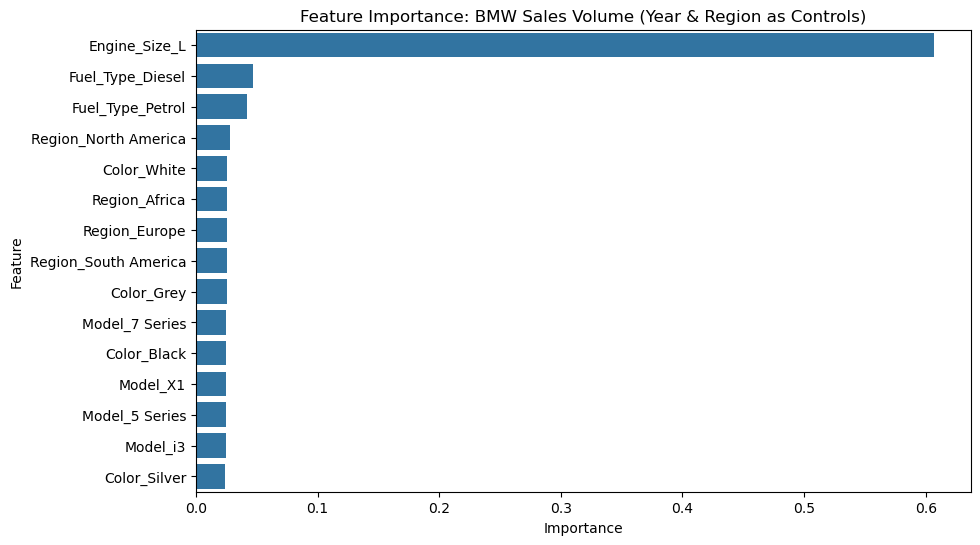

In [46]:
feature_importance = pd.DataFrame({
    'Feature': Selected_Features,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)



plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance: BMW Sales Volume (Year & Region as Controls)')
plt.show()